<a href="https://colab.research.google.com/github/Ashikul-Naim2/wav2ve2-SER-model/blob/main/Wav2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import shutil
import os


drive.mount('/content/drive')


DRIVE_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"
LOCAL_PATH = "/content/Anoted_Imotion_Dataset"


shutil.rmtree(LOCAL_PATH, ignore_errors=True)
shutil.copytree(DRIVE_PATH, LOCAL_PATH)

print(f"Dataset copied to {LOCAL_PATH}")

Mounted at /content/drive
Dataset copied to /content/Anoted_Imotion_Dataset


Device: cuda


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at harshit345/xlsr-wav2vec-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Labels: {'Angry': 0, 'Excited': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4}
Total audio files: 5000


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train size: 4000 Eval size: 1000
Precomputing train features ...
Precomputing test features ...


Step,Training Loss
50,1.329500
100,1.020300
150,0.910600
200,0.861200
250,0.792900
300,0.810100
350,0.762000
400,0.638200
450,0.540000
500,0.592500


Evaluation metrics: {'eval_loss': 0.3912588059902191, 'eval_accuracy': 0.897, 'eval_f1': 0.8976804092402286, 'eval_runtime': 55.2444, 'eval_samples_per_second': 18.101, 'eval_steps_per_second': 9.051, 'epoch': 3.0}

Classification Report:
              precision    recall  f1-score   support

       Angry       0.88      0.92      0.90       190
     Excited       0.84      0.84      0.84       203
       Happy       0.83      0.87      0.85       199
     Neutral       0.98      0.94      0.96       198
         Sad       0.96      0.91      0.94       210

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



<Figure size 1000x800 with 0 Axes>

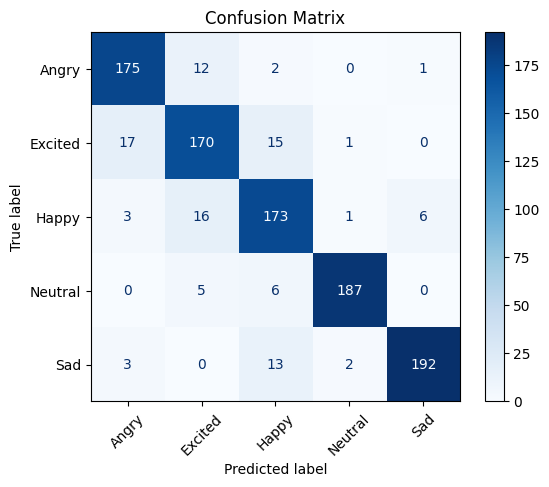

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and feature extractor saved to: /content/drive/MyDrive/wav2vec2-ser-model


In [ ]:

!pip install -q "transformers==4.57.3" "datasets" "torchaudio" librosa soundfile evaluate scikit-learn matplotlib

import os
import random
import librosa
import numpy as np
import torch
from datasets import Dataset, DatasetDict
import evaluate
from transformers import (
    AutoConfig,
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import drive


# Config


DATASET_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"
MODEL_NAME = "harshit345/xlsr-wav2vec-speech-emotion-recognition"
OUTPUT_DIR = "/content/drive/MyDrive/wav2vec2-ser-model"
SAMPLE_RATE = 16000
SEED = 42
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4
EPOCHS = 3
LEARNING_RATE = 5e-5
MAX_AUDIO_LENGTH = 160000




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# LOAD MODEL & FEATURE EXTRACTOR


config = AutoConfig.from_pretrained(MODEL_NAME)
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
model = AutoModelForAudioClassification.from_pretrained(MODEL_NAME, config=config).to(device)


# label mapping


label_dirs = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
if not label_dirs:
    raise RuntimeError(f"No label folders found in {DATASET_PATH}")
label2id = {lab: idx for idx, lab in enumerate(label_dirs)}
id2label = {idx: lab for lab, idx in label2id.items()}
print("Labels:", label2id)


# Dataset


paths, labels = [], []
for lab in label_dirs:
    folder = os.path.join(DATASET_PATH, lab)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith((".wav", ".mp3", ".flac", ".ogg"))])
    paths.extend(files)
    labels.extend([label2id[lab]] * len(files))

print("Total audio files:", len(paths))


ds = Dataset.from_dict({"path": paths, "label": labels})


def load_audio(example):
    speech, sr = librosa.load(example["path"], sr=SAMPLE_RATE, mono=True)
    example["array"] = speech.astype(np.float32)
    example["sampling_rate"] = SAMPLE_RATE
    return example

ds = ds.map(load_audio)

ds_split = ds.train_test_split(test_size=0.2, seed=SEED)
dataset = DatasetDict({"train": ds_split["train"], "test": ds_split["test"]})

print("Train size:", len(dataset["train"]), "Eval size:", len(dataset["test"]))


# PRECOMPUTE FEATURES


precomp_dir = "./precomputed_wav2vec_feats"
os.makedirs(precomp_dir, exist_ok=True)

def precompute_and_save(split_name, ds_split):
    X, y = [], []
    for ex in ds_split:
        arr = ex["array"]
        feats = feature_extractor(arr, sampling_rate=ex["sampling_rate"], return_tensors=None)
        X.append(np.array(feats["input_values"][0], dtype=np.float32))
        y.append(int(ex["label"]))
    np.savez(os.path.join(precomp_dir, f"{split_name}_feats.npz"), X=np.array(X, dtype=object), y=np.array(y, dtype=np.int64), allow_pickle=True)
    return X, y

print("Precomputing train features ...")
train_X, train_y = precompute_and_save("train", dataset["train"])
print("Precomputing test features ...")
test_X, test_y = precompute_and_save("test", dataset["test"])


ds_train = Dataset.from_dict({"input_values": train_X, "label": train_y})
ds_test = Dataset.from_dict({"input_values": test_X, "label": test_y})
dataset = DatasetDict({"train": ds_train, "test": ds_test})


# DATA COLLATOR


def data_collator(batch):
    max_len = min(max(len(b["input_values"]) for b in batch), MAX_AUDIO_LENGTH)
    padded = np.zeros((len(batch), max_len), dtype=np.float32)
    for i, b in enumerate(batch):
        arr = b["input_values"]
        padded[i, :min(len(arr), max_len)] = arr[:max_len]
    labels = [b["label"] for b in batch]
    return {"input_values": torch.tensor(padded, dtype=torch.float32), "labels": torch.tensor(labels, dtype=torch.long)}


# METRICS


accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)
    labels = eval_pred.label_ids
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}


# TRAINING ARGUMENTS + TRAINER


training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    save_steps=500,
    report_to="none",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

torch.cuda.empty_cache()


# TRAIN


trainer.train()


# EVALUATE


eval_metrics = trainer.evaluate(dataset["test"])
print("Evaluation metrics:", eval_metrics)


preds_output = trainer.predict(dataset["test"])
logits = preds_output.predictions
if isinstance(logits, tuple):
    logits = logits[0]
y_pred = np.argmax(logits, axis=1)
y_true = np.array(dataset["test"]["label"])

print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=label_dirs))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_dirs)
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# SAVE MODEL & FEATURE EXTRACTOR TO DRIVE


drive.mount('/content/drive')
os.makedirs(OUTPUT_DIR, exist_ok=True)

trainer.save_model(OUTPUT_DIR)
feature_extractor.save_pretrained(OUTPUT_DIR)

print(" Model and feature extractor saved to:", OUTPUT_DIR)


Load model

In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/wav2vec2-ser-model"

print("Files in model dir:")
for f in os.listdir(MODEL_DIR):
    print(f)


Files in model dir:
config.json
model.safetensors
training_args.bin
preprocessor_config.json
checkpoint-500
checkpoint-1000
checkpoint-1500


In [ ]:
import os
import random
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    AutoConfig,
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
)

# ---------------- CONFIG ----------------
MODEL_DIR = "/content/drive/MyDrive/wav2vec2-ser-model"
DATASET_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"
SAMPLE_RATE = 16000
MAX_LEN = 160000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load model + extractor
config = AutoConfig.from_pretrained(MODEL_DIR)
processor = AutoFeatureExtractor.from_pretrained(MODEL_DIR)
model = AutoModelForAudioClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

id2label = config.id2label
print("Loaded labels:", id2label)


Device: cuda


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loaded labels: {0: 'anger', 1: 'disgust', 2: 'fear', 3: 'happiness', 4: 'sadness'}


XAI


In [ ]:
def get_random_audio():
    emotion = random.choice(os.listdir(DATASET_PATH))
    folder = os.path.join(DATASET_PATH, emotion)
    wavs = [f for f in os.listdir(folder) if f.endswith(".wav")]
    file = random.choice(wavs)
    return os.path.join(folder, file)

sample_path = get_random_audio()
print("Selected audio:", sample_path)


Selected audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Angry/angry_0262.wav


In [ ]:
def saliency_map(model, processor, audio_path, id2label):
    model.eval()

    # Load audio
    audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE)

    # Prepare input
    inputs = processor(audio, sampling_rate=SAMPLE_RATE, return_tensors="pt").input_values.to(device)
    inputs.requires_grad_()

    # Forward pass
    outputs = model(inputs)
    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    label = id2label[pred]

    # Backward for saliency
    logits[0, pred].backward()
    grads = inputs.grad
    saliency = grads.abs().squeeze().cpu().numpy()

    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))
    plt.plot(saliency)
    plt.title(f"Saliency Map - Predicted: {label}")
    plt.xlabel("Time steps")
    plt.ylabel("Gradient magnitude")
    plt.show()


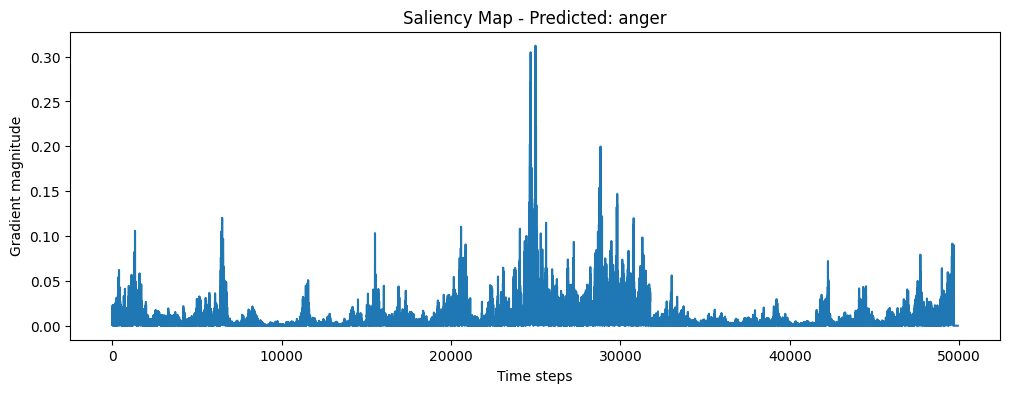

In [ ]:
saliency_map(
    model=model,
    processor=processor,
    audio_path=sample_path,
    id2label=id2label
)


Shap

In [ ]:
!pip install -q shap


In [ ]:

# Recreate label mappings


DATASET_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"

label_dirs = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

label2id = {label: idx for idx, label in enumerate(label_dirs)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label2ID:", label2id)


Label2ID: {'Angry': 0, 'Excited': 1, 'Happy': 2, 'Neutral': 3, 'Sad': 4}



🔍 Emotion: Angry
Audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Angry/angry_0282.wav


  0%|          | 0/1 [00:00<?, ?it/s]

Predicted: Angry


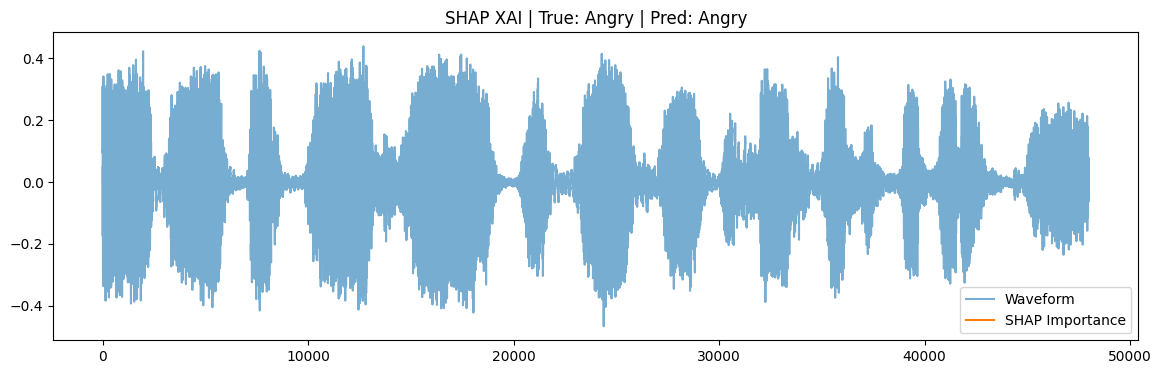


🔍 Emotion: Excited
Audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Excited/excited_0403.wav


  0%|          | 0/1 [00:00<?, ?it/s]

Predicted: Excited


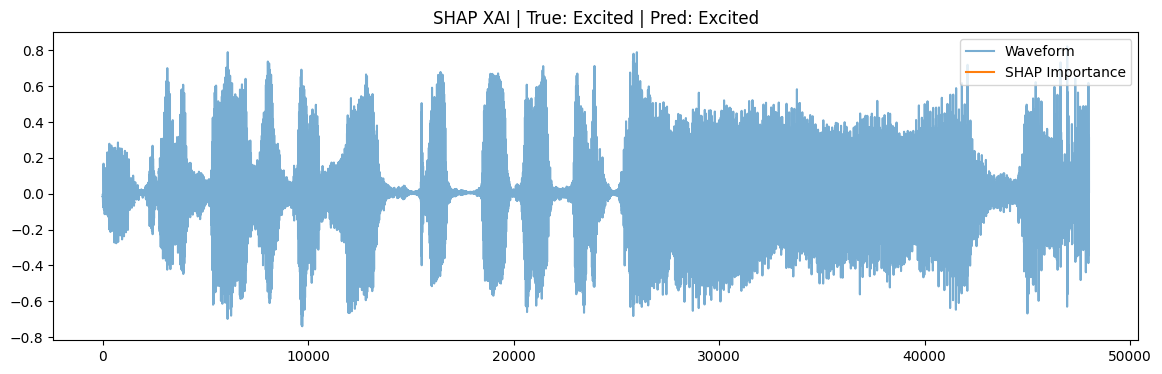


🔍 Emotion: Happy
Audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Happy/happy_0845.wav


  0%|          | 0/1 [00:00<?, ?it/s]

Predicted: Sad


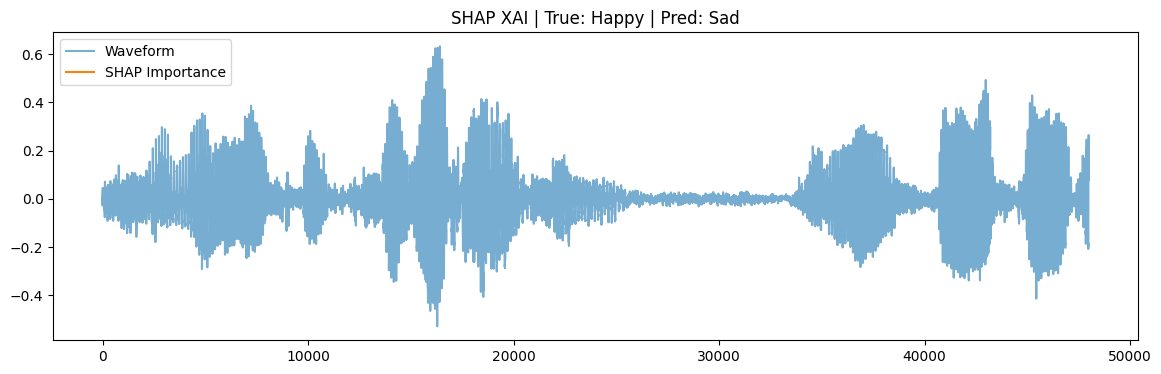


🔍 Emotion: Neutral
Audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Neutral/neutral_0569.wav


  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=4.460e+00, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=9.804e-02, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=5.249e+00, with an active set of 3 regressors, and the smallest cholesky pivot element being 2

Predicted: Sad


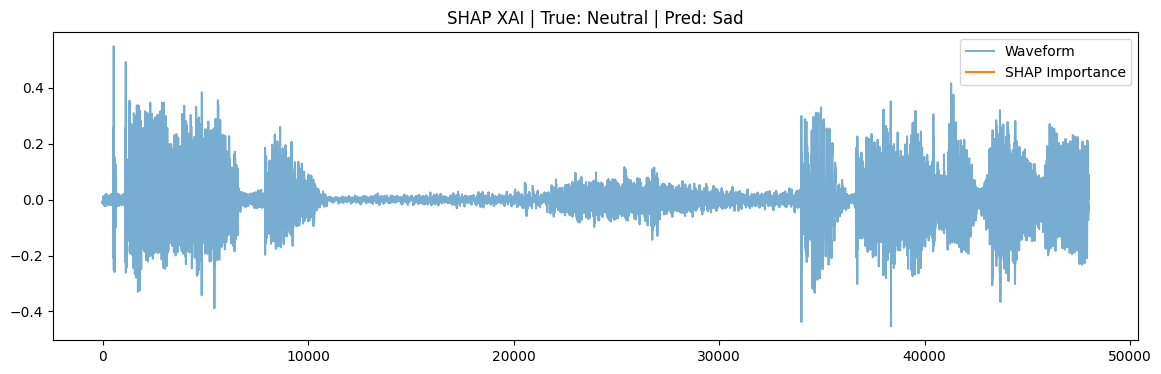


🔍 Emotion: Sad
Audio: /content/drive/MyDrive/Anoted_Imotion_Dataset/Sad/sad_0429.wav


  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=5.165e+00, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=1.542e-02, with an active set of 5 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=9.696e+00, with an active set of 5 regressors, and the smallest cholesky pivot element being 2

Predicted: Sad


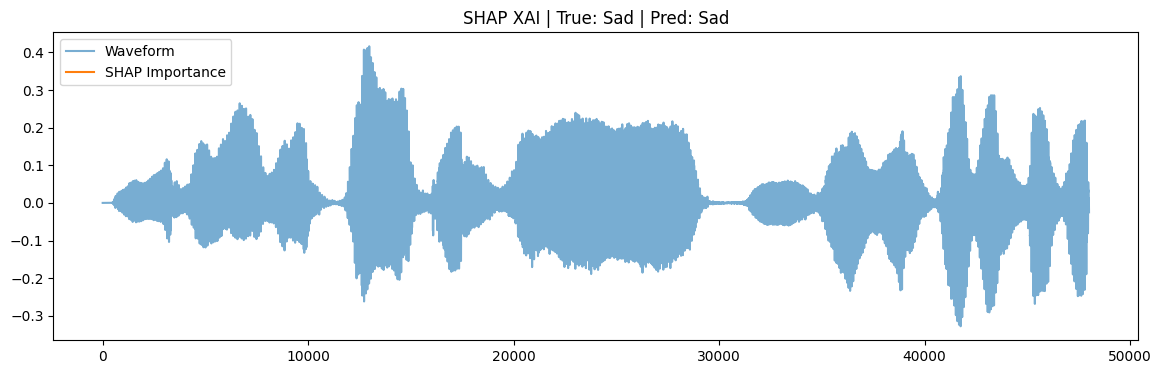

In [ ]:

# SHAP XAI FOR ALL EMOTION CLASSES




import os
import random
import librosa
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt


# CONFIG

DATASET_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"
SAMPLE_RATE = 16000
MAX_LEN = SAMPLE_RATE * 3


# MODEL TO CPU

model.eval()
model = model.cpu()
device = "cpu"


# SHAP PREDICT FUNCTION

def predict_fn(waveforms_np):
    with torch.no_grad():
        inputs = torch.tensor(waveforms_np, dtype=torch.float32)
        outputs = model(inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        return probs.numpy()

# Background (baseline)
background = np.zeros((1, MAX_LEN), dtype=np.float32)
explainer = shap.KernelExplainer(predict_fn, background)


# LOOP OVER EACH CLASS

for emotion, emotion_id in label2id.items():

    emotion_dir = os.path.join(DATASET_PATH, emotion)
    wav_files = [f for f in os.listdir(emotion_dir) if f.endswith(".wav")]

    if len(wav_files) == 0:
        continue

    sample_file = random.choice(wav_files)
    sample_path = os.path.join(emotion_dir, sample_file)

    print(f"\n Emotion: {emotion}")
    print("Audio:", sample_path)

    # Load audio
    audio, _ = librosa.load(sample_path, sr=SAMPLE_RATE)

    if len(audio) > MAX_LEN:
        audio = audio[:MAX_LEN]
    else:
        audio = np.pad(audio, (0, MAX_LEN - len(audio)))

    audio = audio.astype(np.float32)

    # SHAP
    shap_values = explainer.shap_values(
        audio.reshape(1, -1),
        nsamples=50
    )

    # Prediction
    with torch.no_grad():
        logits = model(torch.tensor(audio).unsqueeze(0)).logits
        pred = torch.argmax(logits, dim=1).item()

    print("Predicted:", id2label[pred])

    # Plot
    plt.figure(figsize=(14,4))
    plt.plot(audio, alpha=0.6, label="Waveform")

    shap_importance = np.sum(np.abs(shap_values), axis=0)[0]
    plt.plot(shap_importance, label="SHAP Importance")

    plt.title(f"SHAP XAI | True: {emotion} | Pred: {id2label[pred]}")
    plt.legend()
    plt.show()


In [ ]:
!pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
print(model.config.id2label)
print(model.config.label2id)

{0: 'anger', 1: 'disgust', 2: 'fear', 3: 'happiness', 4: 'sadness'}
{'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'sadness': 4}


In [ ]:
import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt
import torch

from lime.lime_tabular import LimeTabularExplainer

# ==========================
# CONFIG
# ==========================

DATASET_PATH = "/content/drive/MyDrive/Anoted_Imotion_Dataset"

SAMPLE_RATE = 16000
MAX_LEN = SAMPLE_RATE * 3

device = torch.device("cpu")
model = model.to(device)
model.eval()

# Get labels
id2label = model.config.id2label
label2id = model.config.label2id

# ==========================
# Segment settings
# ==========================

SEGMENT_SIZE = 400
NUM_SEGMENTS = MAX_LEN // SEGMENT_SIZE

# Background data
background = np.zeros((10, NUM_SEGMENTS))

explainer = LimeTabularExplainer(
    training_data=background,
    mode="classification",
    discretize_continuous=False,
)

# ==========================
# Prediction function
# ==========================

def predict_fn(segment_vectors):

    audios = []

    for vec in segment_vectors:

        waveform = np.repeat(vec, SEGMENT_SIZE)

        waveform = waveform[:MAX_LEN]

        if len(waveform) < MAX_LEN:
            waveform = np.pad(
                waveform,
                (0, MAX_LEN-len(waveform))
            )

        audios.append(waveform)

    inputs = processor(
        audios,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():

        logits = model(**inputs).logits

        probs = torch.softmax(logits, dim=-1)

    return probs.cpu().numpy()

# ==========================
# Loop over emotions
# ==========================

for emotion in label2id.keys():

    emotion_folder = os.path.join(DATASET_PATH, emotion)

    if not os.path.exists(emotion_folder):
        print(f"Folder not found: {emotion_folder}")
        continue

    wav_files = [
        f for f in os.listdir(emotion_folder)
        if f.endswith(".wav")
    ]

    if len(wav_files)==0:
        continue

    sample = random.choice(wav_files)

    filepath = os.path.join(emotion_folder, sample)

    print("\nEmotion:", emotion)
    print("File:", sample)

    audio, sr = librosa.load(
        filepath,
        sr=SAMPLE_RATE
    )

    if len(audio) > MAX_LEN:
        audio = audio[:MAX_LEN]
    else:
        audio = np.pad(
            audio,
            (0, MAX_LEN-len(audio))
        )

    audio = audio.astype(np.float32)

    # waveform -> segments
    segments = audio.reshape(NUM_SEGMENTS, SEGMENT_SIZE)

    segment_features = np.mean(
        segments,
        axis=1
    )

    explanation = explainer.explain_instance(
        segment_features,
        predict_fn,
        num_features=20,
        num_samples=500
    )

    # Actual prediction
    inputs = processor(
        audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt"
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():

        logits = model(**inputs).logits

        pred = torch.argmax(logits,1).item()

    print("Predicted:", id2label[pred])

    # Importance values
    weights = np.zeros(NUM_SEGMENTS)

    for idx, weight in explanation.local_exp[pred]:
        weights[idx] = weight

    importance = np.repeat(
        weights,
        SEGMENT_SIZE
    )

    importance = importance[:MAX_LEN]

    plt.figure(figsize=(14,4))

    plt.plot(audio,
             label="Waveform",
             alpha=0.6)

    plt.plot(
        importance,
        linewidth=2,
        label="LIME Importance"
    )

    plt.title(
        f"LIME | True: {emotion} | Pred: {id2label[pred]}"
    )

    plt.legend()

    plt.show()

Folder not found: /content/drive/MyDrive/Anoted_Imotion_Dataset/anger
Folder not found: /content/drive/MyDrive/Anoted_Imotion_Dataset/disgust
Folder not found: /content/drive/MyDrive/Anoted_Imotion_Dataset/fear
Folder not found: /content/drive/MyDrive/Anoted_Imotion_Dataset/happiness
Folder not found: /content/drive/MyDrive/Anoted_Imotion_Dataset/sadness
